In [ ]:
import pandas as pd
import nltk
import re
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**ARQUIVOS**

In [ ]:
df = pd.read_csv('Cem_Anos_de_Perdao.csv')

**PRÉ-PROCESSAMENTO**

*   Remoção de pontuação
*   Remoção de palavras irrelevantes

In [ ]:
texto = df.iloc[:,0].astype(str)

In [ ]:
def processamento_texto(texto, stem=False, lemma=False):
    texto = re.sub(r'[^\w\s]','', texto.lower())
    stop_words = set(stopwords.words('portuguese'))
    tokens = nltk.word_tokenize(texto)
    tokens = [word for word in tokens if word not in stop_words]

    if stem:
        ps = PorterStemmer()
        tokens = [ps.stem(word) for word in tokens]

    if lemma:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

In [ ]:
limp_texto = texto.apply(lambda x: processamento_texto(x))
deriv_texto= texto.apply(lambda x: processamento_texto(x, stem=True))
lemma_texto = texto.apply(lambda x: processamento_texto(x, lemma=True))

**FREQUÊNCIA DO TERMO**

In [ ]:
def frequencia_termo(texto, title, ngram_range=(1,1), top_n=15):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(texto)
    termo = vectorizer.get_feature_names_out()
    frequencia = X.sum(axis=0).A1
    term_freq = pd.DataFrame({'Termo': termo, 'Frequência': frequencia})
    top_termos = term_freq.nlargest(top_n, 'Frequência')


    fig = px.bar(top_termos, x='Termo', y='Frequência', title=title)
    fig.show()

In [ ]:
frequencia_termo(limp_texto, 'Frequência do Termo: Tokenização e limpeza')
frequencia_termo(deriv_texto, 'Frequência do Termo: Tokenização e derivados')
frequencia_termo(lemma_texto, 'Frequência do Termo: Tokenização e lemmatização')

**FREQUÊNCIA DOS TERMOS DE ACORDO COM OS SEGUINTES N-GRAM:**

*  Unigram (1,1)
*  Unigram e Bigram (1,2)
*  Bigram (1,1)
*  Bigram e Trigram (2,3)

In [ ]:
frequencia_termo(limp_texto, 'TF-IDF Unigrams (1,1)', ngram_range=(1,1))
frequencia_termo(limp_texto, 'TF-IDF Unigrams and Bigrams (1,2)', ngram_range=(1,2))
frequencia_termo(limp_texto, 'TF-IDF Bigrams (2,2)', ngram_range=(2,2))
frequencia_termo(limp_texto, 'TF-IDF Bigrams and Trigrams (2,3)', ngram_range=(2,3))

**WORLDCLOUD - NÚVEM DE PALAVRAS**

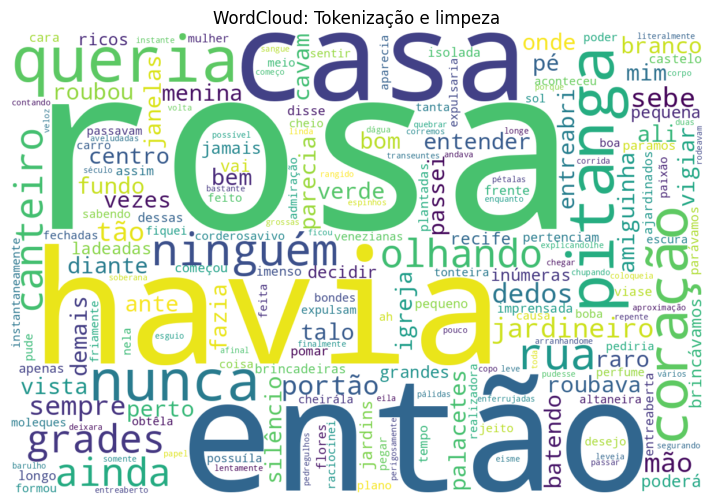

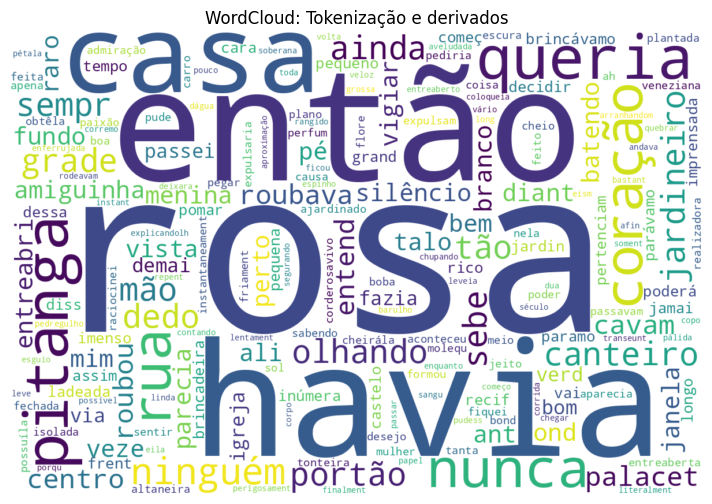

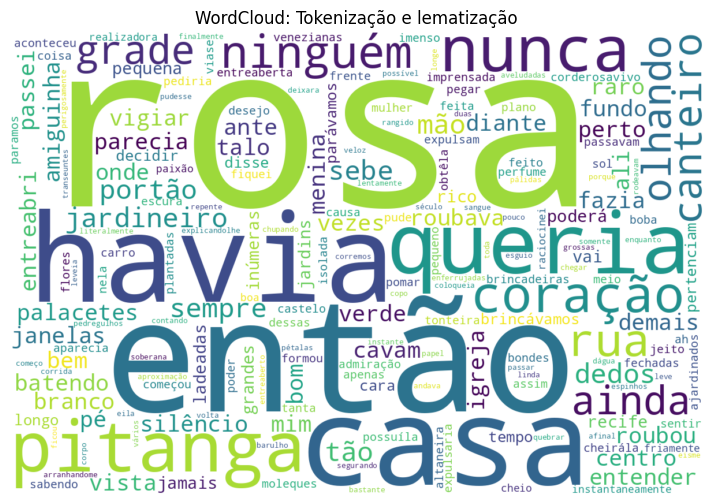

In [ ]:
def gerar_nuvem_palavras(texto, title):
    nuvem_palavras = WordCloud(width=1200, height=800, background_color='white').generate(' '.join(texto))
    plt.figure(figsize=(10, 6))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

gerar_nuvem_palavras(limp_texto, 'WordCloud: Tokenização e limpeza')
gerar_nuvem_palavras(deriv_texto, 'WordCloud: Tokenização e derivados')
gerar_nuvem_palavras(lemma_texto, 'WordCloud: Tokenização e lematização')

**NORMALIZAÇÃO L1 E L2**

In [ ]:
def compare_l1_l2(texto, ngram_range=(1,1)):
    vectorizer_l1 = TfidfVectorizer(norm='l1', ngram_range=ngram_range)
    vectorizer_l2 = TfidfVectorizer(norm='l2', ngram_range=ngram_range)
    X_l1 = vectorizer_l1.fit_transform(texto)
    X_l2 = vectorizer_l2.fit_transform(texto)

    norm_l1 = X_l1.sum(axis=1).A1.mean()
    norm_l2 = (X_l2.multiply(X_l2)).sum(axis=1).A1.mean()

    print(f"Mean L1 norm: {norm_l1}")
    print(f"Mean L2 norm: {norm_l2}")

compare_l1_l2(limp_texto, ngram_range=(1,1))
compare_l1_l2(limp_texto, ngram_range=(1,2))
compare_l1_l2(limp_texto, ngram_range=(2,2))
compare_l1_l2(limp_texto, ngram_range=(2,3))

Mean L1 norm: 1.0
Mean L2 norm: 1.0
Mean L1 norm: 1.0
Mean L2 norm: 1.0
Mean L1 norm: 0.9655172413793104
Mean L2 norm: 0.9655172413793104
Mean L1 norm: 0.9655172413793104
Mean L2 norm: 0.9655172413793104


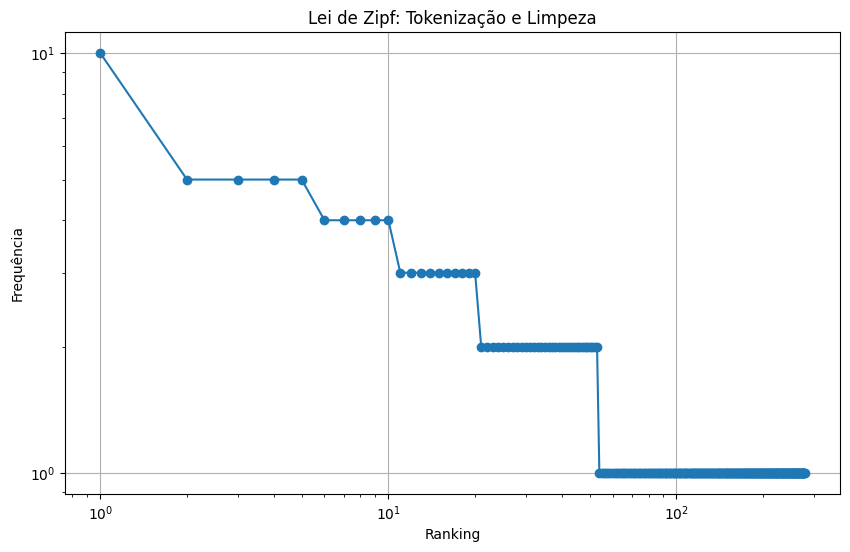

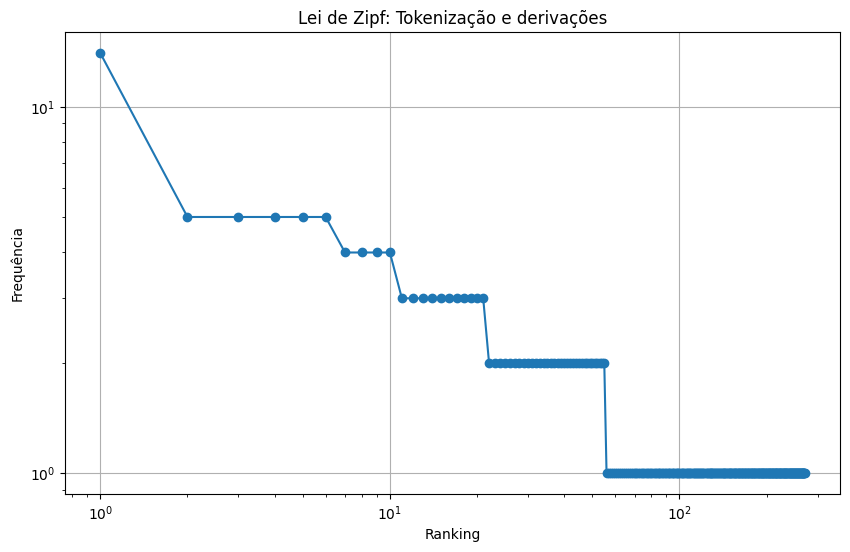

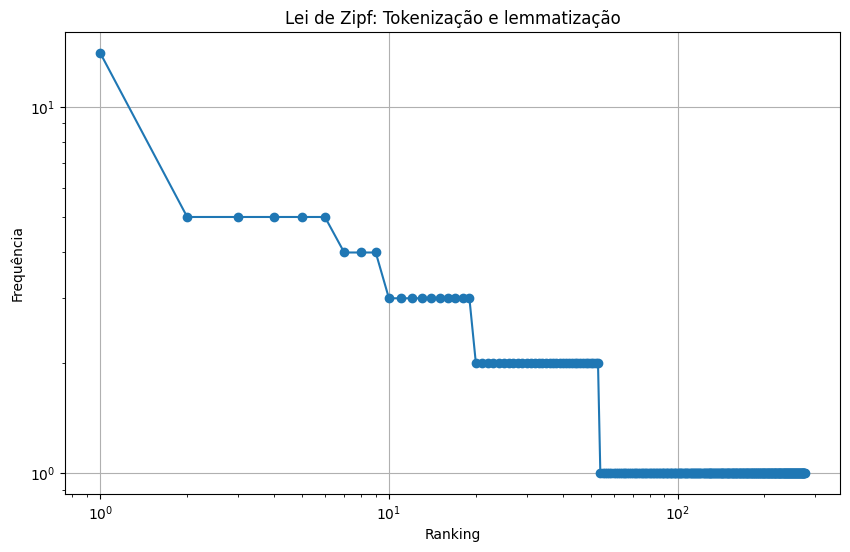

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

def lei_zipf(texto, title):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(texto)
    word_freq = np.asarray(X.sum(axis=0)).flatten()

    sorted_freq = np.sort(word_freq)[::-1]
    ranks = np.arange(1, len(sorted_freq) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(ranks, sorted_freq, marker="o")
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f"Lei de Zipf: {title}")
    plt.xlabel("Ranking")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.show()

lei_zipf(limp_texto, "Tokenização e Limpeza")
lei_zipf(deriv_texto, "Tokenização e derivações")
lei_zipf(lemma_texto, "Tokenização e lemmatização")

**RESULTADO SEM O STOPWORDS**

> Adicionar aspas



In [ ]:
def frequencia_termo_sem_stopwords(texto, title, ngram_range=(1,1), top_n=15):

    vectorizer = TfidfVectorizer(ngram_range=ngram_range, stop_words=None)
    X = vectorizer.fit_transform(texto)

    termo = vectorizer.get_feature_names_out()
    frequencia = X.sum(axis=0).A1
    term_freq = pd.DataFrame({'Termo': termo, 'Frequência': frequencia})

    top_termos = term_freq.nlargest(top_n, 'Frequência')

    fig = px.bar(top_termos, x='Termo', y='Frequência', title=title)
    fig.show()

frequencia_termo_sem_stopwords(df['Sentenças'], "Termos mais frequentes (sem stopwords)", ngram_range=(1,1), top_n=15)
